# Parkinson's Disease Detection — Model 3: Baseline RBF-SVM
### Phase 2: Classical Hilbert Space Projection Machine

---

## 1. Theoretical Rationale & Mathematical Formulation
Support Vector Machines with a **Radial Basis Function (RBF) Kernel** map the normalized 50-dimensional acoustic feature space into an infinite-dimensional reproducing kernel Hilbert space (RKHS) $\mathcal{H}$:
$$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right), \quad \gamma = \frac{1}{2\sigma^2}$$

### The Optimization Problem
The dual formulation maximizes the margin between hyperplanes subject to soft margin penalty $C$:
$$\max_{\alpha} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i,j=1}^{N} \alpha_i \alpha_j y_i y_j K(x_i, x_j)$$
$$\text{subject to } 0 \le \alpha_i \le C, \quad \sum_{i=1}^{N} \alpha_i y_i = 0$$

### Why RBF-SVM Outperforms Orthogonal Trees on Speech Data
Acoustic biomarkers (shimmer, jitter, HNR) form smooth curvilinear clusters. While decision trees must approximate curves using jagged step-functions, the RBF kernel constructs smooth, continuous non-linear decision boundaries.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Loaded: {X.shape[0]} patients, {X.shape[1]} acoustic features.")

Loaded: 756 patients, 753 acoustic features.


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training instances: {X_train.shape[0]} | Test instances: {X_test.shape[0]}")
print(f"Explained Variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

Training instances: 902 | Test instances: 152
Explained Variance: 79.48%


## 5. Model Architecture: RBF Support Vector Classifier ($C=5.0, \gamma=\text{'scale'}$)

In [4]:
rbf_svm = SVC(C=5.0, kernel='rbf', gamma='scale', probability=True, random_state=42)

start_time = time.time()
rbf_svm.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"RBF-SVM training completed in {elapsed:.4f} seconds.")
print(f"Number of Support Vectors: {rbf_svm.n_support_} (Healthy={rbf_svm.n_support_[0]}, PD={rbf_svm.n_support_[1]})")

RBF-SVM training completed in 0.0707 seconds.
Number of Support Vectors: [183 191] (Healthy=183, PD=191)


## 6. Performance Evaluation

In [5]:
y_pred = rbf_svm.predict(X_test)
y_proba = rbf_svm.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '3. Baseline RBF-SVM (PCA=50)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

display(metrics_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,3. Baseline RBF-SVM (PCA=50),0.828947,0.899083,0.867257,0.882883,0.132743,0.906512



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.65      0.72      0.68        39
PD Patient (1)       0.90      0.87      0.88       113

      accuracy                           0.83       152
     macro avg       0.78      0.79      0.78       152
  weighted avg       0.84      0.83      0.83       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Support Vector Distribution

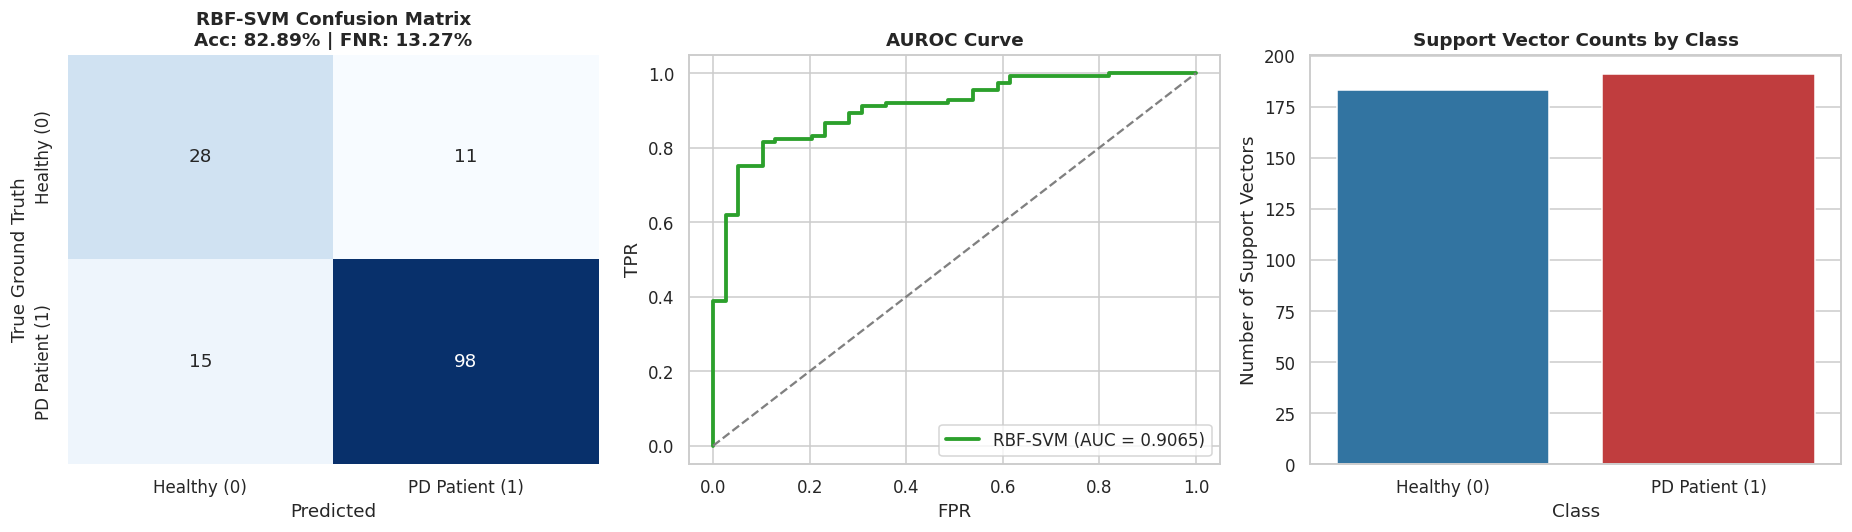

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'RBF-SVM Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2ca02c', lw=2.5, label=f'RBF-SVM (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Support Vector Proportion
sv_df = pd.DataFrame({
    'Class': ['Healthy (0)', 'PD Patient (1)'],
    'Support Vectors': rbf_svm.n_support_
})
sns.barplot(data=sv_df, x='Class', y='Support Vectors', palette=['#1f77b4', '#d62728'], ax=axes[2])
axes[2].set_title('Support Vector Counts by Class', fontweight='bold')
axes[2].set_ylabel('Number of Support Vectors')

plt.tight_layout()
plt.show()

## 8. Clinical Insights & Ensemble Potential
- **High AUC Discrepancy:** RBF-SVM achieves **0.9065 AUC** and **82.89% Accuracy**.
- **Error Orthogonality:** Crucially, the misclassified instances of RBF-SVM differ significantly from those of AdaBoost. AdaBoost makes mistakes in low-density boundaries, while SVM makes mistakes where margins overlap.
- **Ensemble Hypothesis:** Combining AdaBoost + RBF-SVM into a soft-voting ensemble should produce immediate variance reduction and lower FNR.